# MIA Distributions Plots

In [4]:
import os
from pathlib import Path
import pandas as pd
import json

model_name = "Llama-3.2-1B-Instruct"
splits = [
    ("retain90", "forget10"),
    ("retain95", "forget05"),
    ("retain99", "forget01")
]
temperatures = [1.3, 2, 3, 4]
files = [
    "saves/eval/tofu_{model_name}_{retain_split}_temp_{temperature}/TOFU_EVAL.json",
]

extracted_data = []

def get_values(data, key, split):
    try:
        return [value['score'] for value in data[key][split]['value_by_index'].values()]
    except KeyError:
        return []


for retain_split, forget_split in splits:
    for temperature in temperatures:
        for file in files:
            file = file.format(model_name=model_name, retain_split=retain_split, temperature=temperature)
            if not os.path.exists(file):
                print(f"File {file} does not exist. Skipping.")
                continue
            
            with open(file, 'r') as f:
                data = json.load(f)

            extracted_data.append({
                "model": model_name,
                "retain_split": retain_split,
                "forget_split": forget_split,
                "temperature": temperature,
                "mia_min_k_forget": get_values(data, 'mia_min_k', 'forget'),
                "mia_min_k_holdout": get_values(data, 'mia_min_k', 'holdout'),
                "mia_min_k_plus_plus_forget": get_values(data, 'mia_min_k_plus_plus', 'forget'),
                "mia_min_k_plus_plus_holdout": get_values(data, 'mia_min_k_plus_plus', 'holdout'),
                "mia_loss_forget": get_values(data, 'mia_loss', 'forget'),
                "mia_loss_holdout": get_values(data, 'mia_loss', 'holdout'),
            })

df = pd.DataFrame(extracted_data)
display(df)



,model,retain_split,forget_split,temperature,mia_min_k_forget,mia_min_k_holdout,mia_min_k_plus_plus_forget,mia_min_k_plus_plus_holdout,mia_loss_forget,mia_loss_holdout
0,Llama-3.2-1B-Instruct,retain90,forget10,1.3,"[6.544325828552246, 2.8352322578430176, 2.7993...","[2.818114995956421, 5.692259788513184, 5.51601...","[2.118912696838379, 1.4399707317352295, 0.6300...","[0.9352203607559204, 4.952016353607178, 8.9230...","[2.9497745037078857, 1.02029550075531, 1.00425...","[0.9887373447418213, 1.9979679584503174, 2.157..."
1,Llama-3.2-1B-Instruct,retain90,forget10,2.0,"[6.544325828552246, 2.8352322578430176, 2.7993...","[2.818114995956421, 5.692259788513184, 5.51601...","[2.118912696838379, 1.4399707317352295, 0.6300...","[0.9352203607559204, 4.952016353607178, 8.9230...","[2.9497745037078857, 1.02029550075531, 1.00425...","[0.9887373447418213, 1.9979679584503174, 2.157..."
2,Llama-3.2-1B-Instruct,retain90,forget10,3.0,"[6.544325828552246, 2.8352322578430176, 2.7993...","[2.818114995956421, 5.692259788513184, 5.51601...","[2.118912696838379, 1.4399707317352295, 0.6300...","[0.9352203607559204, 4.952016353607178, 8.9230...","[2.9497745037078857, 1.02029550075531, 1.00425...","[0.9887373447418213, 1.9979679584503174, 2.157..."
3,Llama-3.2-1B-Instruct,retain90,forget10,4.0,"[6.544325828552246, 2.8352322578430176, 2.7993...","[2.818114995956421, 5.692259788513184, 5.51601...","[2.118912696838379, 1.4399707317352295, 0.6300...","[0.9352203607559204, 4.952016353607178, 8.9230...","[2.9497745037078857, 1.02029550075531, 1.00425...","[0.9887373447418213, 1.9979679584503174, 2.157..."
4,Llama-3.2-1B-Instruct,retain95,forget05,1.3,"[4.232850551605225, 5.729892730712891, 2.37279...","[2.6514296531677246, 5.540210247039795, 5.6859...","[0.47203898429870605, 5.7999043464660645, 0.53...","[0.7590981721878052, 4.989058971405029, 7.5791...","[1.9219361543655396, 1.7927680015563965, 0.860...","[0.9295886754989624, 1.9443690776824951, 2.231..."
5,Llama-3.2-1B-Instruct,retain95,forget05,2.0,"[4.232850551605225, 5.729892730712891, 2.37279...","[2.6514296531677246, 5.540210247039795, 5.6859...","[0.47203898429870605, 5.7999043464660645, 0.53...","[0.7590981721878052, 4.989058971405029, 7.5791...","[1.9219361543655396, 1.7927680015563965, 0.860...","[0.9295886754989624, 1.9443690776824951, 2.231..."
6,Llama-3.2-1B-Instruct,retain95,forget05,3.0,"[4.232850551605225, 5.729892730712891, 2.37279...","[2.6514296531677246, 5.540210247039795, 5.6859...","[0.47203898429870605, 5.7999043464660645, 0.53...","[0.7590981721878052, 4.989058971405029, 7.5791...","[1.9219361543655396, 1.7927680015563965, 0.860...","[0.9295886754989624, 1.9443690776824951, 2.231..."
7,Llama-3.2-1B-Instruct,retain95,forget05,4.0,"[4.232850551605225, 5.729892730712891, 2.37279...","[2.6514296531677246, 5.540210247039795, 5.6859...","[0.47203898429870605, 5.7999043464660645, 0.53...","[0.7590981721878052, 4.989058971405029, 7.5791...","[1.9219361543655396, 1.7927680015563965, 0.860...","[0.9295886754989624, 1.9443690776824951, 2.231..."
8,Llama-3.2-1B-Instruct,retain99,forget01,1.3,"[3.7943274974823, 3.031870126724243, 0.8203489...","[2.639354944229126, 5.252169609069824, 5.48699...","[3.275702714920044, 3.2888131141662598, 0.0408...","[0.708000659942627, 4.166831016540527, 7.37757...","[1.4801380634307861, 1.0829306840896606, 0.273...","[0.9258552193641663, 1.8435766696929932, 2.183..."
9,Llama-3.2-1B-Instruct,retain99,forget01,2.0,"[3.7943274974823, 3.031870126724243, 0.8203489...","[2.639354944229126, 5.252169609069824, 5.48699...","[3.275702714920044, 3.2888131141662598, 0.0408...","[0.708000659942627, 4.166831016540527, 7.37757...","[1.4801380634307861, 1.0829306840896606, 0.273...","[0.9258552193641663, 1.8435766696929932, 2.183..."


## MIA Min-K%

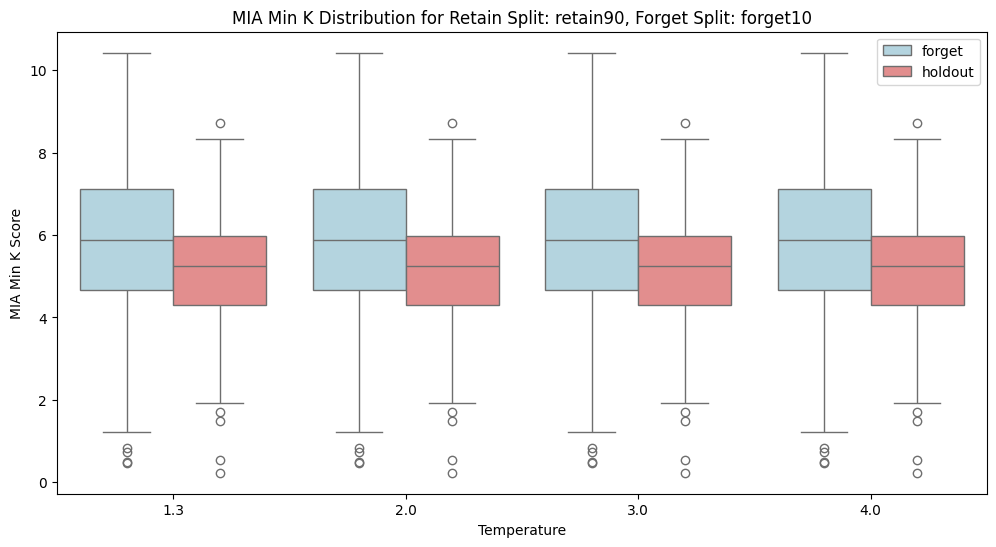

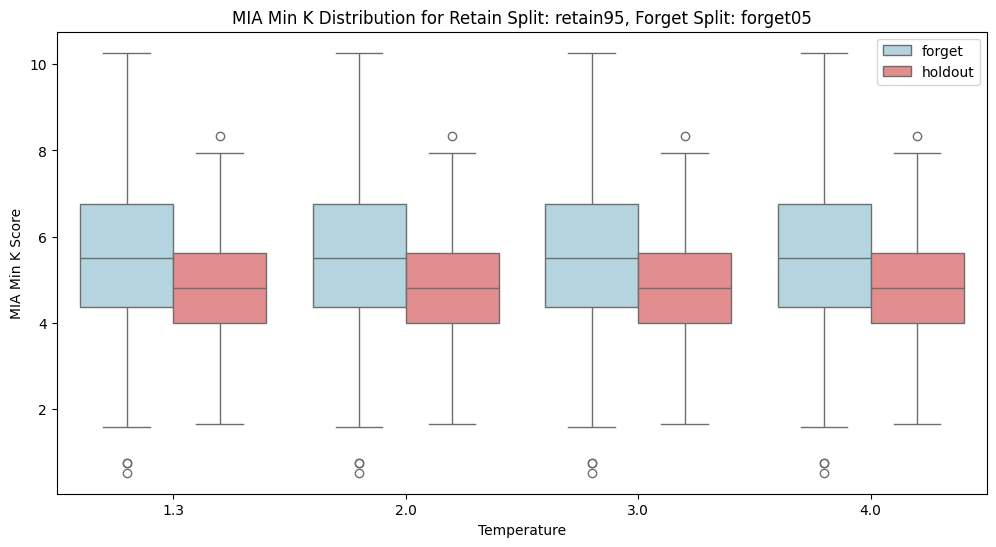

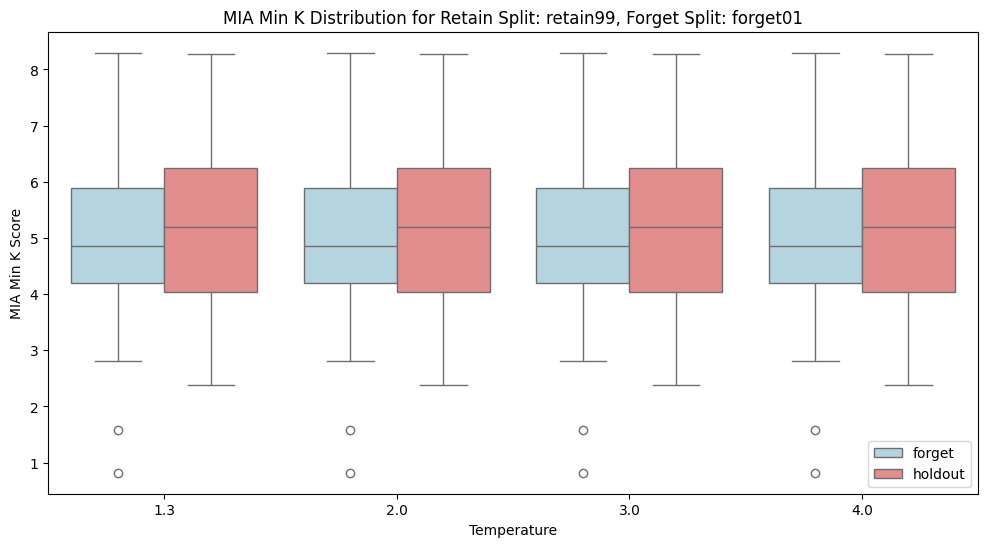

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

for retain_split, forget_split in splits:
    subset = df[(df['retain_split'] == retain_split) & (df['forget_split'] == forget_split)]
    if subset.empty:
        print(f"No data for retain_split={retain_split} and forget_split={forget_split}. Skipping plot.")
        continue

    forget_df = subset[['temperature', 'mia_min_k_forget']].explode('mia_min_k_forget').rename(columns={'mia_min_k_forget': 'score'})
    forget_df['split'] = 'forget'
    holdout_df = subset[['temperature', 'mia_min_k_holdout']].explode('mia_min_k_holdout').rename(columns={'mia_min_k_holdout': 'score'})
    holdout_df['split'] = 'holdout'
    long_df = pd.concat([forget_df, holdout_df], ignore_index=True)
    long_df['score'] = long_df['score'].astype(float)

    plt.figure(figsize=(12, 6))
    sns.boxplot(x='temperature', y='score', hue='split', data=long_df, palette={'forget': 'lightblue', 'holdout': 'lightcoral'})
    plt.title(f'MIA Min K Distribution for Retain Split: {retain_split}, Forget Split: {forget_split}')
    plt.xlabel('Temperature')
    plt.ylabel('MIA Min K Score')
    plt.legend()
    plt.show()


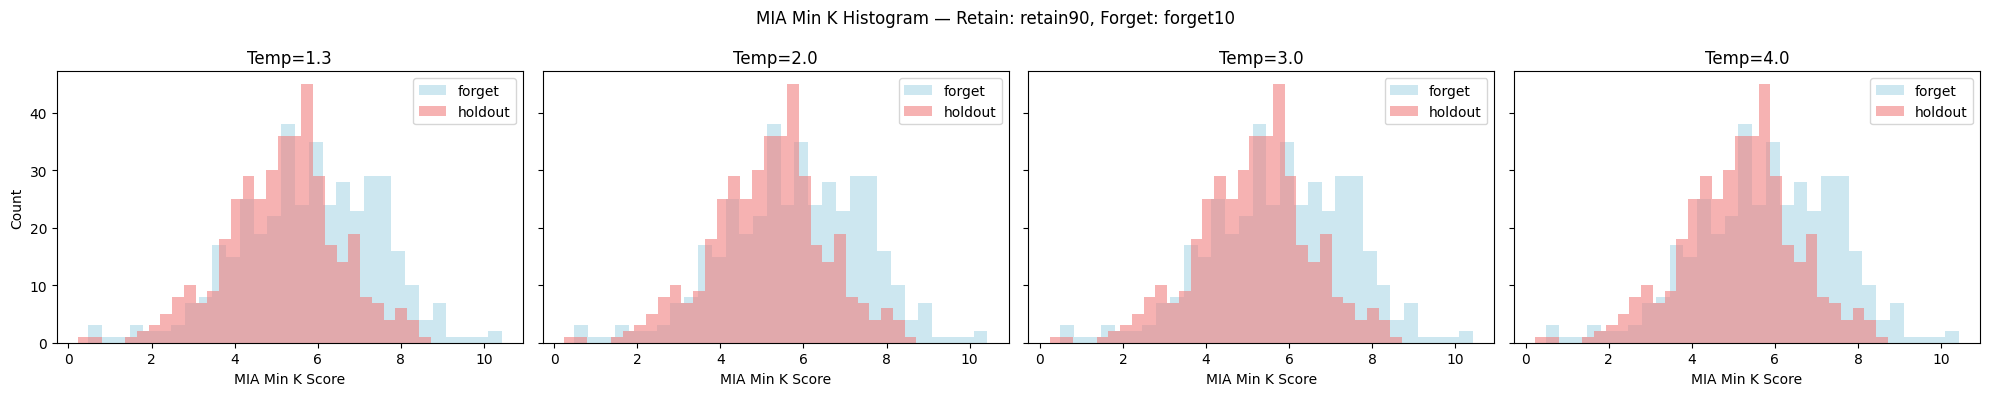

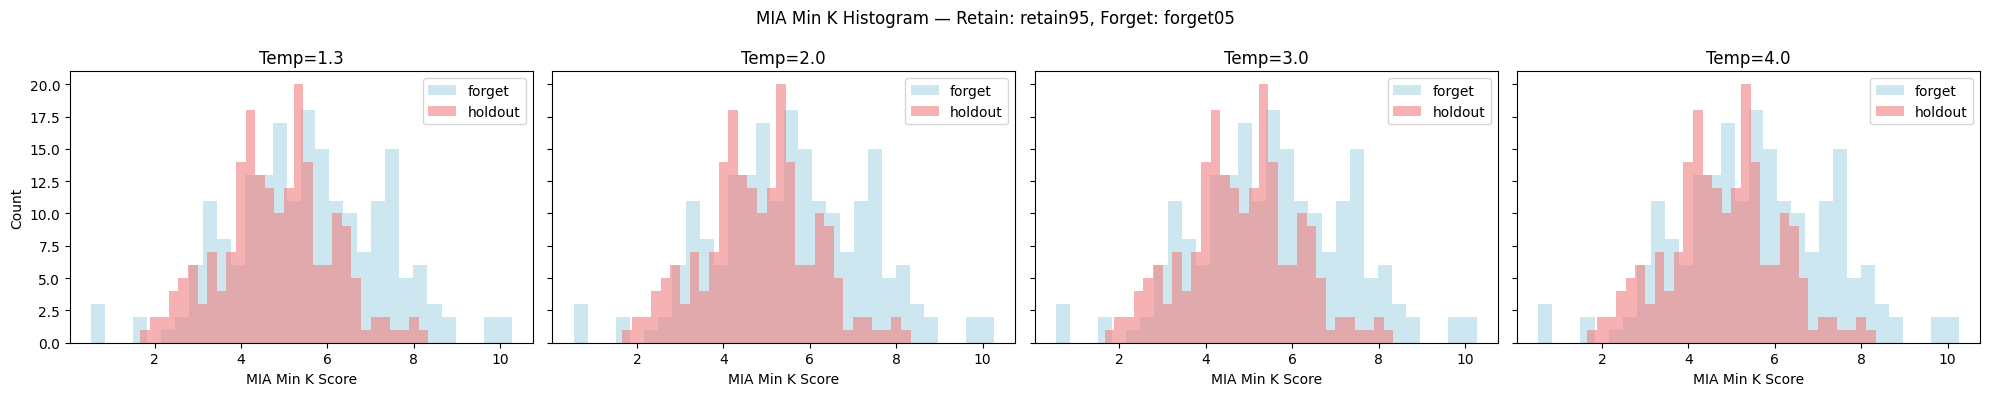

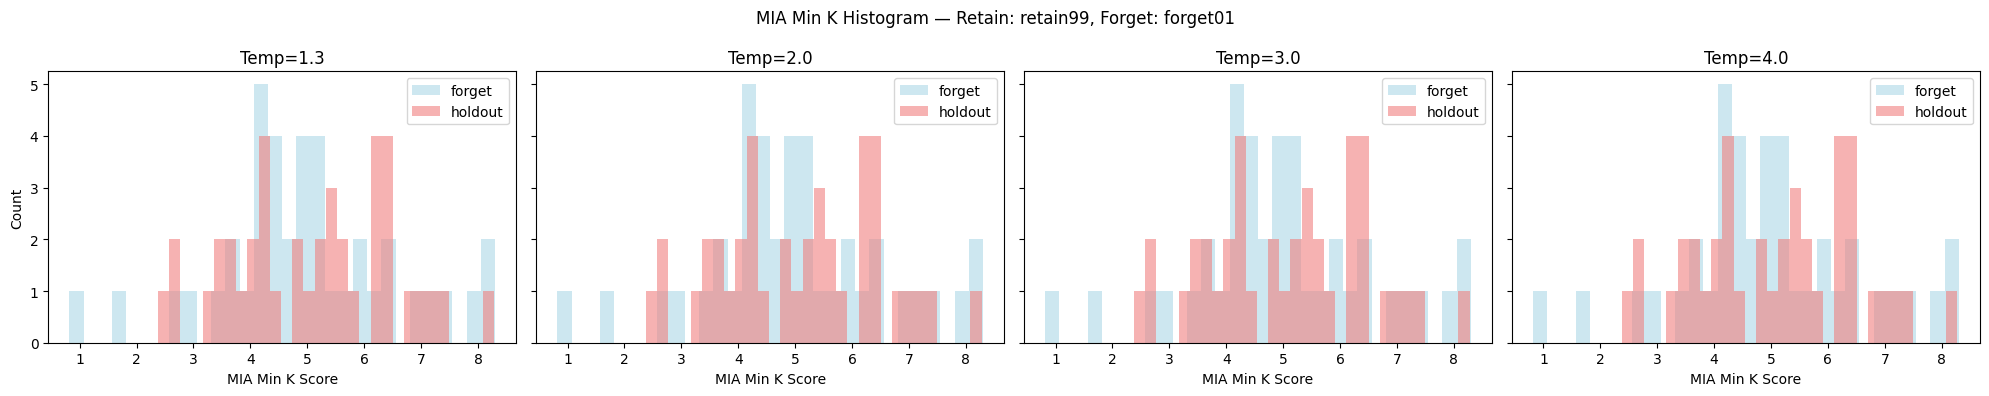

In [3]:
for retain_split, forget_split in splits:
    subset = df[(df['retain_split'] == retain_split) & (df['forget_split'] == forget_split)]
    if subset.empty:
        print(f"No data for retain_split={retain_split} and forget_split={forget_split}. Skipping plot.")
        continue

    forget_df = subset[['temperature', 'mia_min_k_forget']].explode('mia_min_k_forget').rename(columns={'mia_min_k_forget': 'score'})
    forget_df['split'] = 'forget'
    holdout_df = subset[['temperature', 'mia_min_k_holdout']].explode('mia_min_k_holdout').rename(columns={'mia_min_k_holdout': 'score'})
    holdout_df['split'] = 'holdout'
    long_df = pd.concat([forget_df, holdout_df], ignore_index=True)
    long_df['score'] = long_df['score'].astype(float)

    temps = sorted(long_df['temperature'].unique())
    fig, axes = plt.subplots(1, len(temps), figsize=(5 * len(temps), 4), sharey=True)
    if len(temps) == 1:
        axes = [axes]

    for ax, temp in zip(axes, temps):
        temp_df = long_df[long_df['temperature'] == temp]
        for split, color in [('forget', 'lightblue'), ('holdout', 'lightcoral')]:
            scores = temp_df[temp_df['split'] == split]['score']
            ax.hist(scores, bins=30, alpha=0.6, color=color, label=split)
        ax.set_title(f'Temp={temp}')
        ax.set_xlabel('MIA Min K Score')
        ax.legend()

    axes[0].set_ylabel('Count')
    fig.suptitle(f'MIA Min K Histogram — Retain: {retain_split}, Forget: {forget_split}')
    plt.tight_layout()
    plt.show()


## MIA MIN-K%++

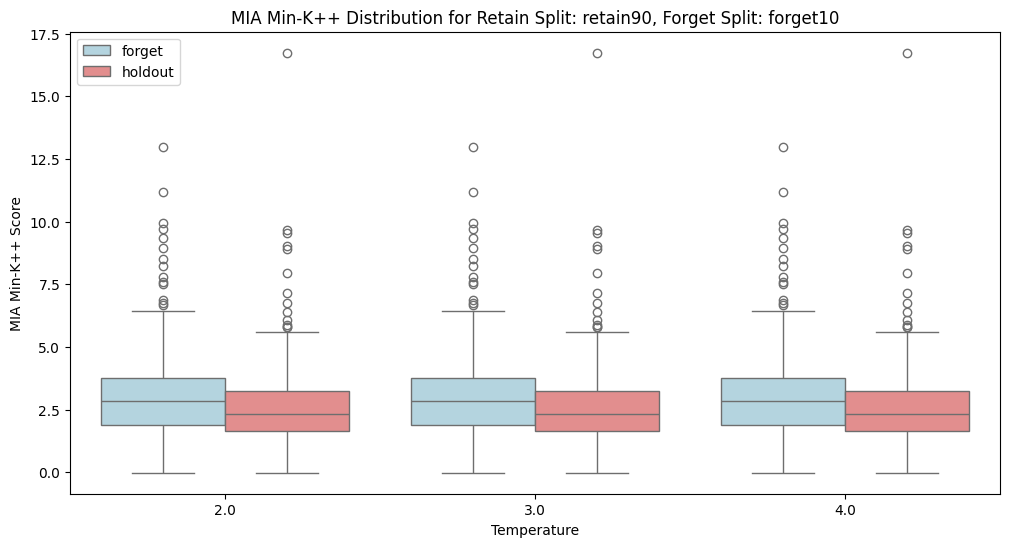

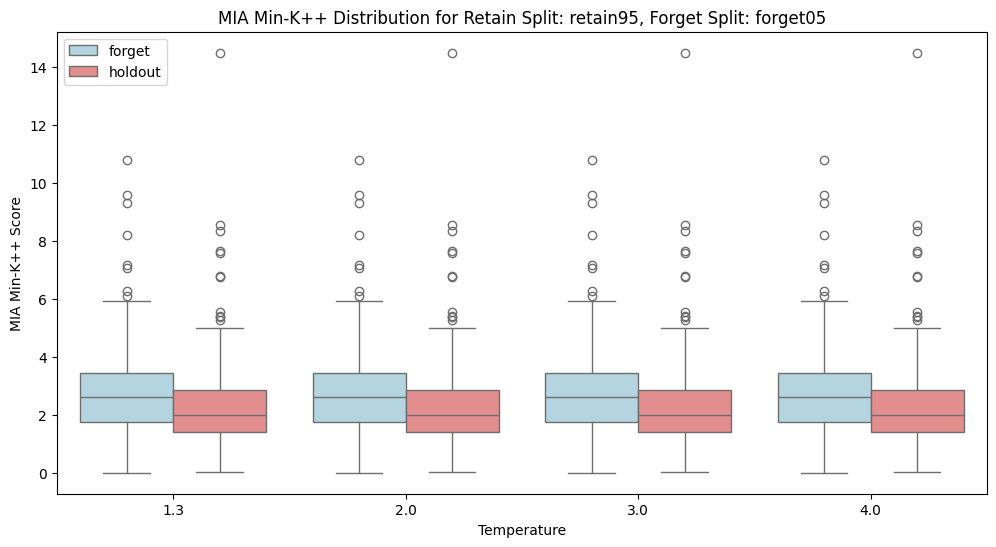

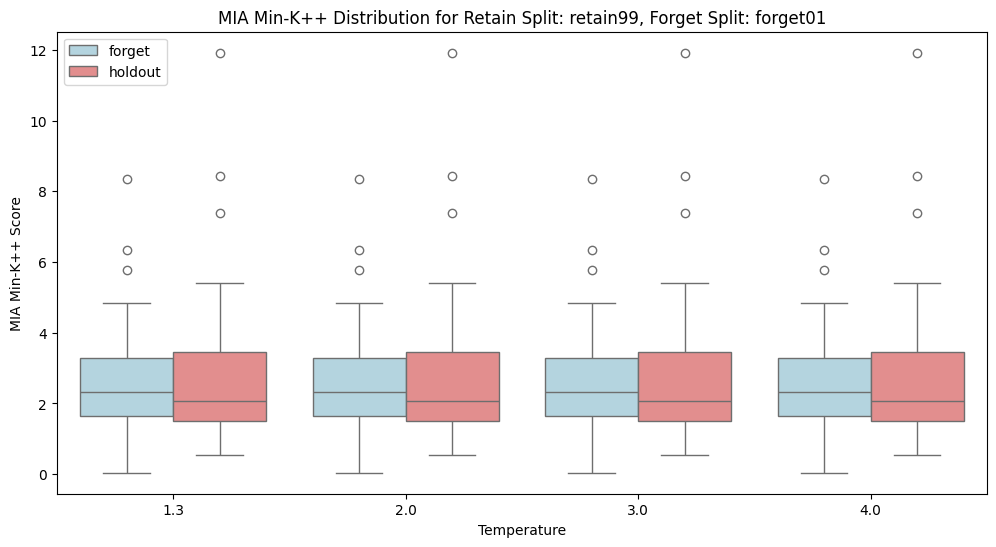

In [9]:
for retain_split, forget_split in splits:
    subset = df[(df['retain_split'] == retain_split) & (df['forget_split'] == forget_split)]
    if subset.empty:
        print(f"No data for retain_split={retain_split} and forget_split={forget_split}. Skipping plot.")
        continue

    forget_df = subset[['temperature', 'mia_min_k_plus_plus_forget']].explode('mia_min_k_plus_plus_forget').rename(columns={'mia_min_k_plus_plus_forget': 'score'})
    forget_df['split'] = 'forget'
    holdout_df = subset[['temperature', 'mia_min_k_plus_plus_holdout']].explode('mia_min_k_plus_plus_holdout').rename(columns={'mia_min_k_plus_plus_holdout': 'score'})
    holdout_df['split'] = 'holdout'
    long_df = pd.concat([forget_df, holdout_df], ignore_index=True)
    long_df['score'] = pd.to_numeric(long_df['score'], errors='coerce')
    long_df = long_df.dropna(subset=['score'])

    plt.figure(figsize=(12, 6))
    sns.boxplot(x='temperature', y='score', hue='split', data=long_df, palette={'forget': 'lightblue', 'holdout': 'lightcoral'})
    plt.title(f'MIA Min-K++ Distribution for Retain Split: {retain_split}, Forget Split: {forget_split}')
    plt.xlabel('Temperature')
    plt.ylabel('MIA Min-K++ Score')
    plt.legend()
    plt.show()


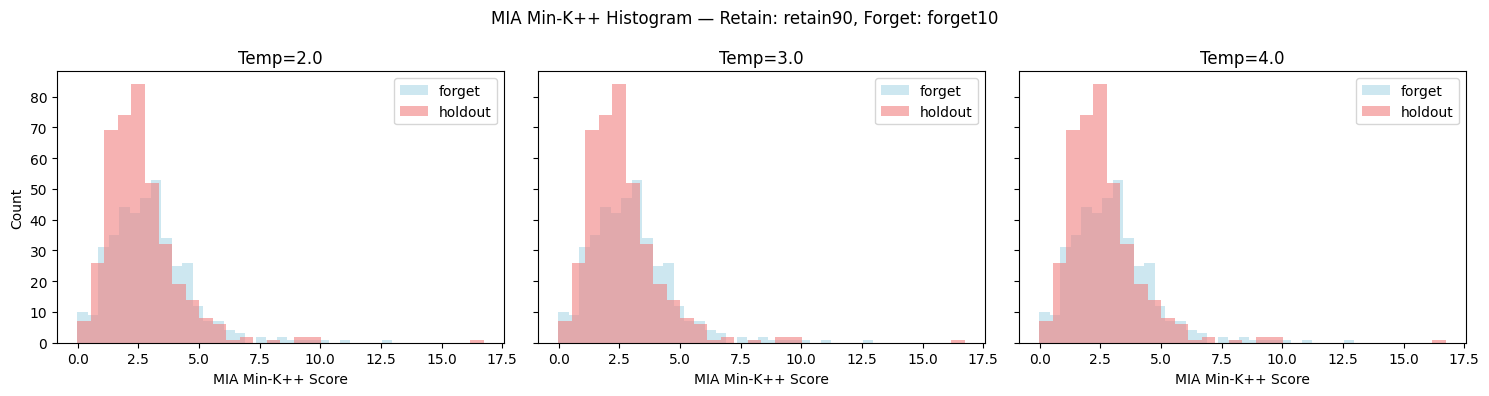

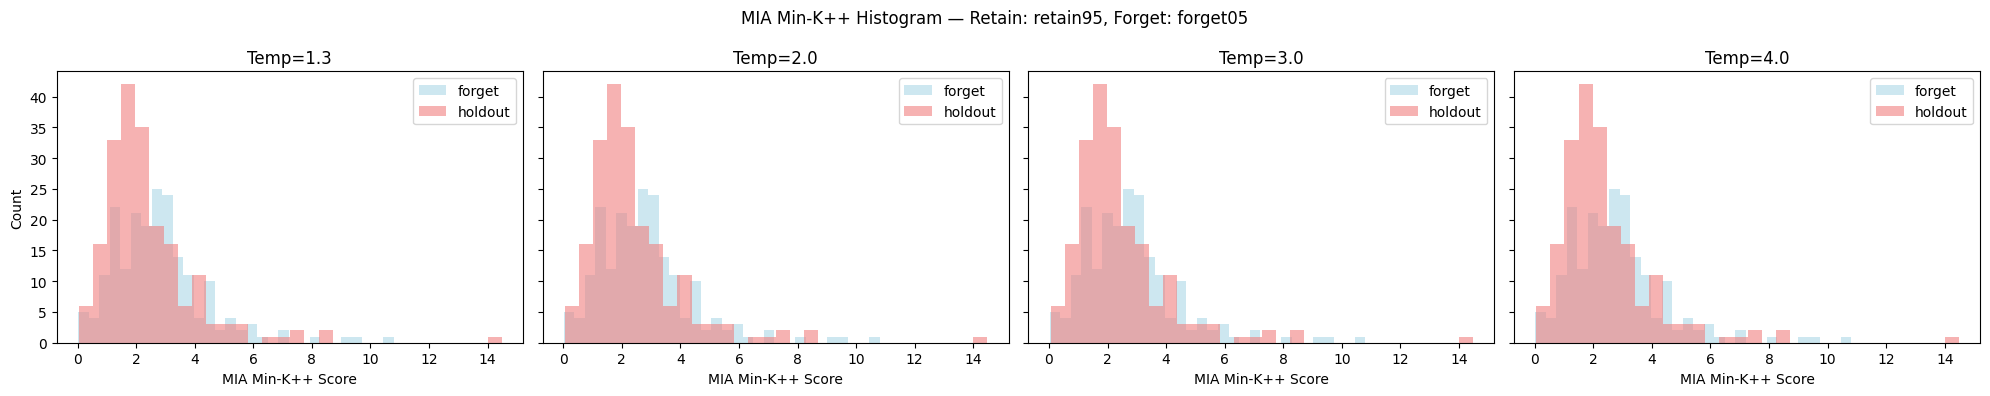

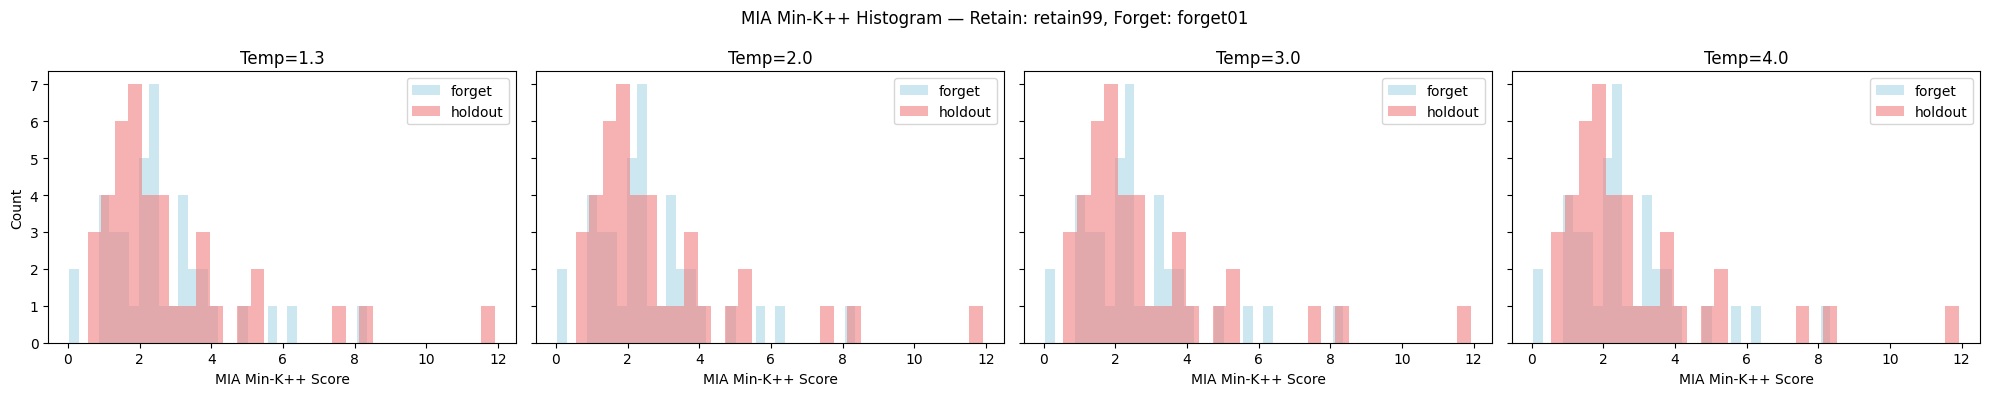

In [10]:
for retain_split, forget_split in splits:
    subset = df[(df['retain_split'] == retain_split) & (df['forget_split'] == forget_split)]
    if subset.empty:
        print(f"No data for retain_split={retain_split} and forget_split={forget_split}. Skipping plot.")
        continue

    forget_df = subset[['temperature', 'mia_min_k_plus_plus_forget']].explode('mia_min_k_plus_plus_forget').rename(columns={'mia_min_k_plus_plus_forget': 'score'})
    forget_df['split'] = 'forget'
    holdout_df = subset[['temperature', 'mia_min_k_plus_plus_holdout']].explode('mia_min_k_plus_plus_holdout').rename(columns={'mia_min_k_plus_plus_holdout': 'score'})
    holdout_df['split'] = 'holdout'
    long_df = pd.concat([forget_df, holdout_df], ignore_index=True)
    long_df['score'] = pd.to_numeric(long_df['score'], errors='coerce')
    long_df = long_df.dropna(subset=['score'])

    temps = sorted(long_df['temperature'].unique())
    fig, axes = plt.subplots(1, len(temps), figsize=(5 * len(temps), 4), sharey=True)
    if len(temps) == 1:
        axes = [axes]

    for ax, temp in zip(axes, temps):
        temp_df = long_df[long_df['temperature'] == temp]
        for split, color in [('forget', 'lightblue'), ('holdout', 'lightcoral')]:
            scores = temp_df[temp_df['split'] == split]['score']
            ax.hist(scores, bins=30, alpha=0.6, color=color, label=split)
        ax.set_title(f'Temp={temp}')
        ax.set_xlabel('MIA Min-K++ Score')
        ax.legend()

    axes[0].set_ylabel('Count')
    fig.suptitle(f'MIA Min-K++ Histogram — Retain: {retain_split}, Forget: {forget_split}')
    plt.tight_layout()
    plt.show()


## MIA Loss

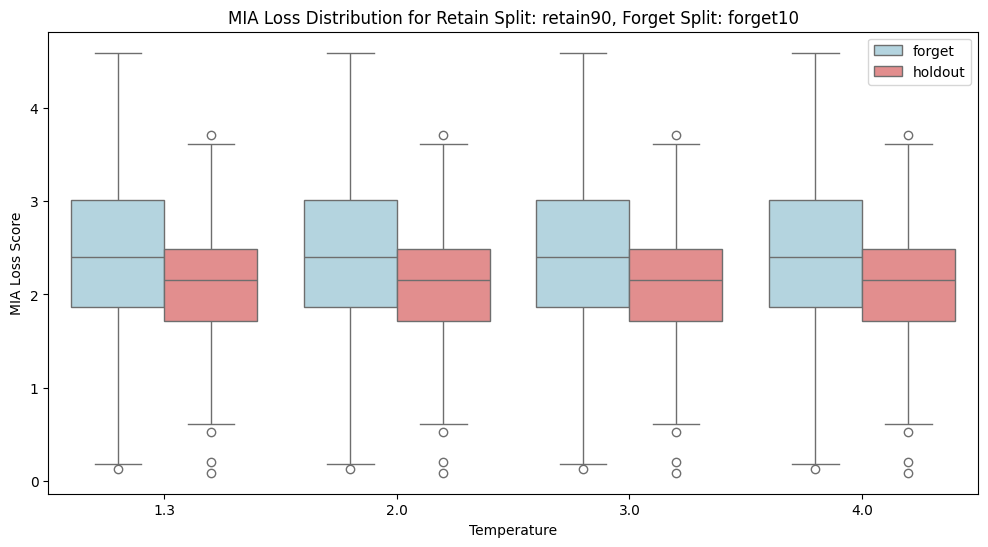

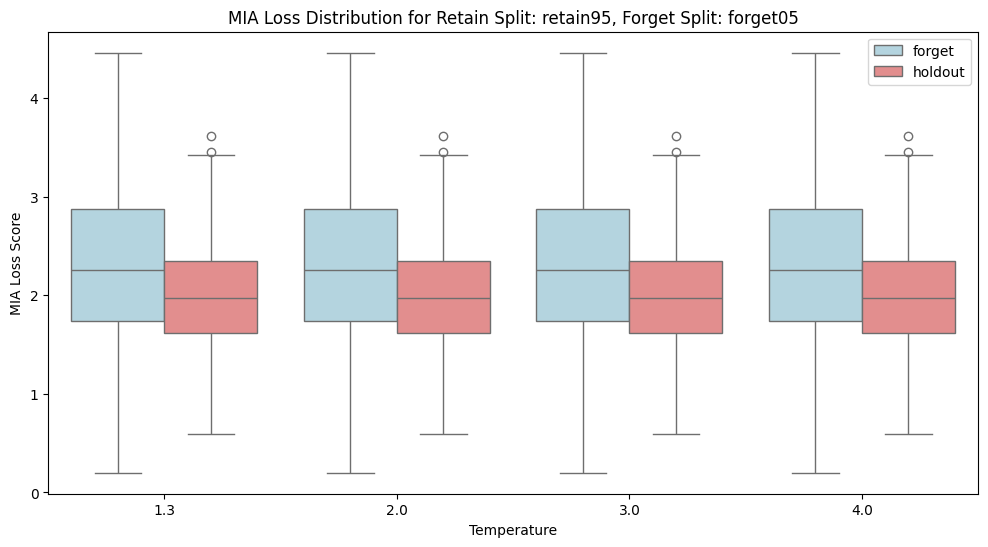

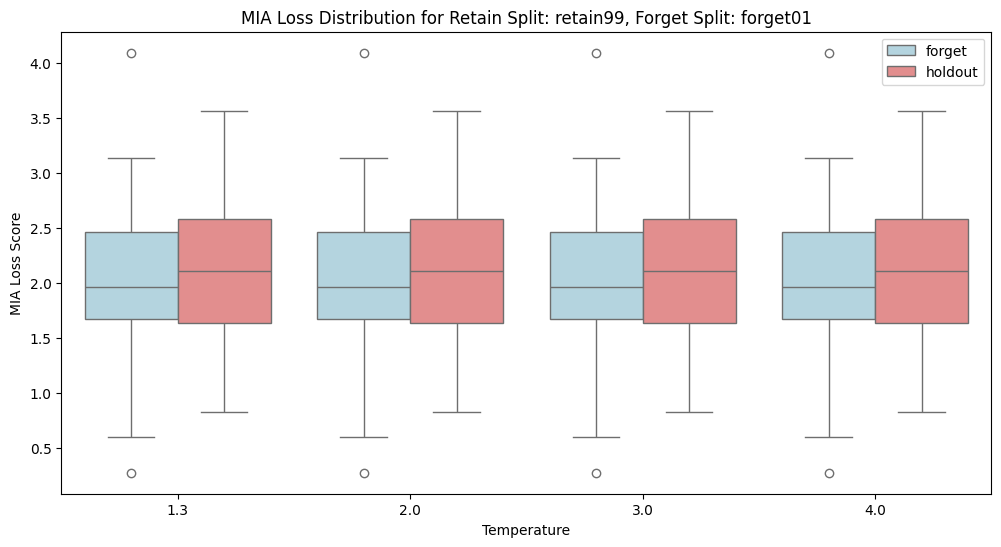

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

for retain_split, forget_split in splits:
    subset = df[(df['retain_split'] == retain_split) & (df['forget_split'] == forget_split)]
    if subset.empty:
        print(f"No data for retain_split={retain_split} and forget_split={forget_split}. Skipping plot.")
        continue

    forget_df = subset[['temperature', 'mia_loss_forget']].explode('mia_loss_forget').rename(columns={'mia_loss_forget': 'score'})
    forget_df['split'] = 'forget'
    holdout_df = subset[['temperature', 'mia_loss_holdout']].explode('mia_loss_holdout').rename(columns={'mia_loss_holdout': 'score'})
    holdout_df['split'] = 'holdout'
    long_df = pd.concat([forget_df, holdout_df], ignore_index=True)
    long_df['score'] = long_df['score'].astype(float)

    plt.figure(figsize=(12, 6))
    sns.boxplot(x='temperature', y='score', hue='split', data=long_df, palette={'forget': 'lightblue', 'holdout': 'lightcoral'})
    plt.title(f'MIA Loss Distribution for Retain Split: {retain_split}, Forget Split: {forget_split}')
    plt.xlabel('Temperature')
    plt.ylabel('MIA Loss Score')
    plt.legend()
    plt.show()


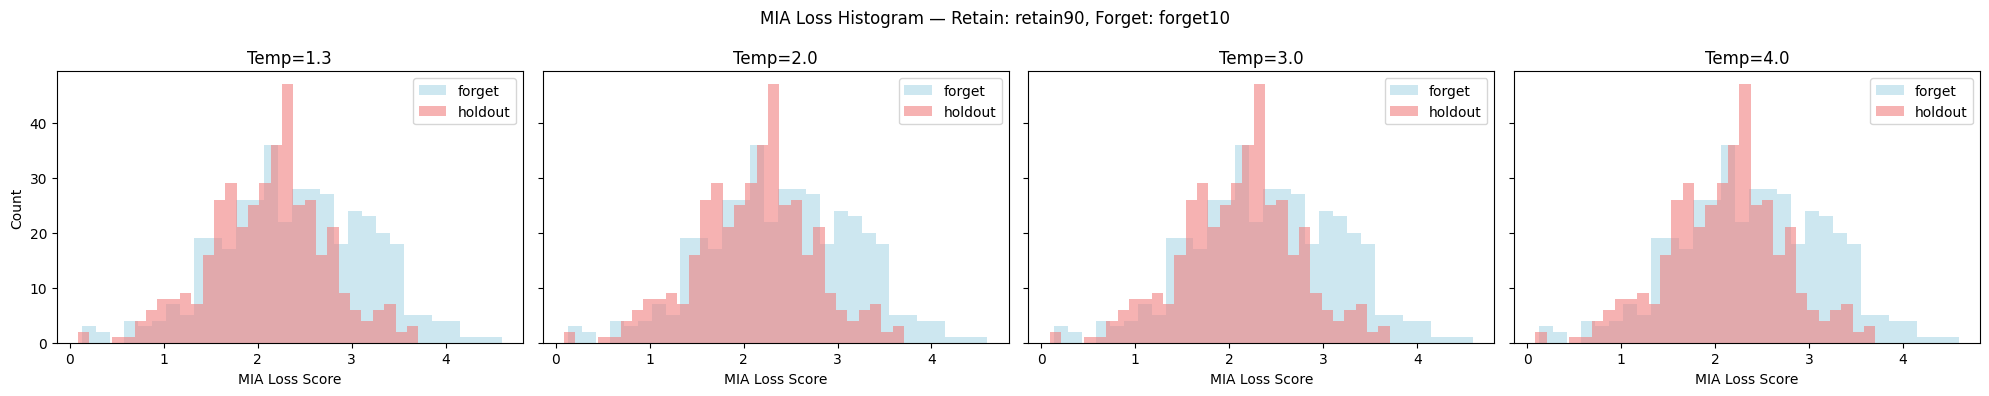

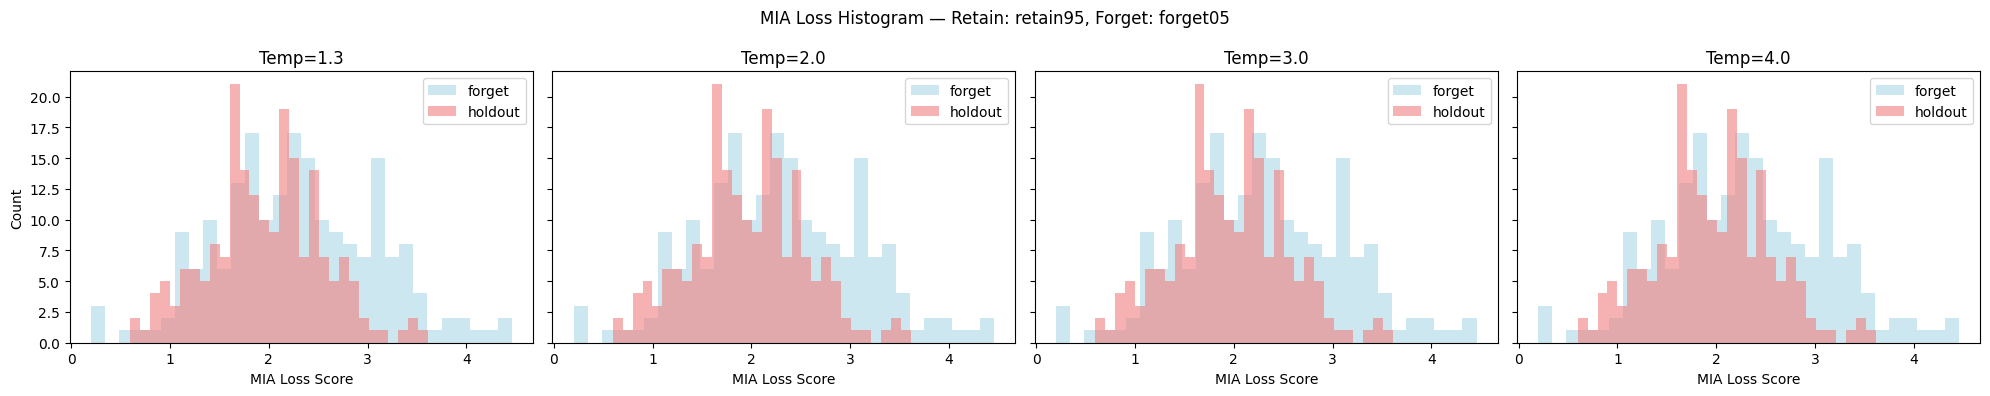

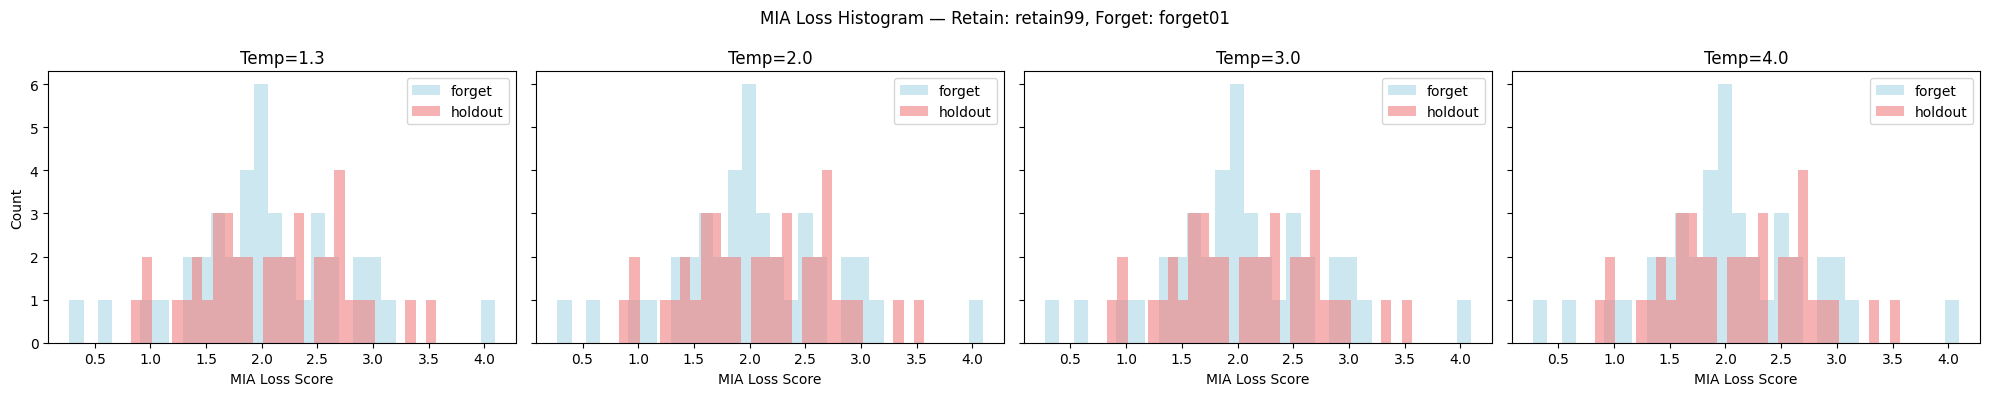

In [6]:
for retain_split, forget_split in splits:
    subset = df[(df['retain_split'] == retain_split) & (df['forget_split'] == forget_split)]
    if subset.empty:
        print(f"No data for retain_split={retain_split} and forget_split={forget_split}. Skipping plot.")
        continue

    forget_df = subset[['temperature', 'mia_loss_forget']].explode('mia_loss_forget').rename(columns={'mia_loss_forget': 'score'})
    forget_df['split'] = 'forget'
    holdout_df = subset[['temperature', 'mia_loss_holdout']].explode('mia_loss_holdout').rename(columns={'mia_loss_holdout': 'score'})
    holdout_df['split'] = 'holdout'
    long_df = pd.concat([forget_df, holdout_df], ignore_index=True)
    long_df['score'] = pd.to_numeric(long_df['score'], errors='coerce')
    long_df = long_df.dropna(subset=['score'])

    temps = sorted(long_df['temperature'].unique())
    fig, axes = plt.subplots(1, len(temps), figsize=(5 * len(temps), 4), sharey=True)
    if len(temps) == 1:
        axes = [axes]

    for ax, temp in zip(axes, temps):
        temp_df = long_df[long_df['temperature'] == temp]
        for split, color in [('forget', 'lightblue'), ('holdout', 'lightcoral')]:
            scores = temp_df[temp_df['split'] == split]['score']
            ax.hist(scores, bins=30, alpha=0.6, color=color, label=split)
        ax.set_title(f'Temp={temp}')
        ax.set_xlabel('MIA Loss Score')
        ax.legend()

    axes[0].set_ylabel('Count')
    fig.suptitle(f'MIA Loss Histogram — Retain: {retain_split}, Forget: {forget_split}')
    plt.tight_layout()
    plt.show()
